# 03 — NL explanation module: Figure A + fast/slow analysis

What this notebook produces:
1. The **hero remember/forget heatmap** (Figure A): global (slow) memory across rounds and attack types.
2. A per-attack **forgetting metric** trajectory (`max-so-far − current`).
3. The **NL fast vs slow** view, with the phase markers, one subplot per attack.
4. The **consolidation gap** |fast − slow| over rounds.
5. A short summary block with the numbers used in the paper.

Inputs:
- `data/processed/round_log.csv` (slow / global)
- `data/processed/fast_log.csv` (fast / per-client local)

Outputs: PNG figures in `figures/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / 'data/processed'
FIG_DIR  = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

slow = pd.read_csv(DATA_DIR/'round_log.csv')
fast = pd.read_csv(DATA_DIR/'fast_log.csv')

ATTACK_TYPES     = ['DoS','Fuzzy','RPM','gear']
N_ROUNDS         = int(slow['round'].max())
ROUNDS_PER_PHASE = N_ROUNDS // len(ATTACK_TYPES)

print(f'slow={slow.shape}, fast={fast.shape}')
print(f'rounds={N_ROUNDS}, phase length={ROUNDS_PER_PHASE}')

slow=(31, 9), fast=(480, 7)
rounds=30, phase length=7


## 1. Figure A — remember/forget heatmap (slow memory)

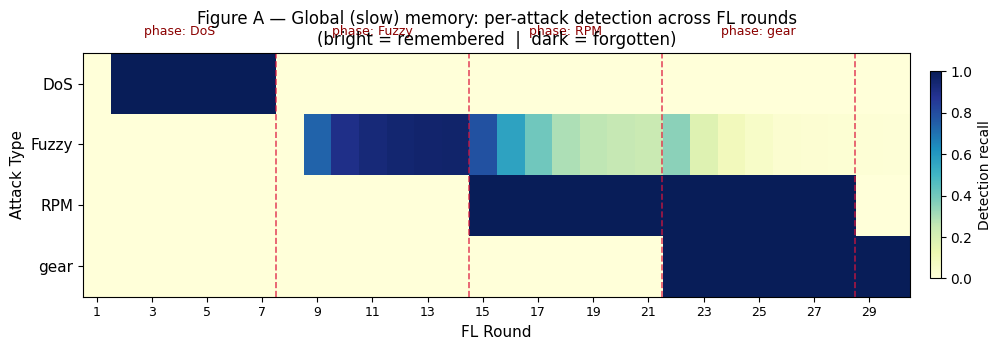

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_A_remember_forget_heatmap.png


In [2]:
# Build matrix: rows = attacks, columns = rounds 1..N
mat = np.array([slow[slow['round']>=1][f'recall_{atk}'].values for atk in ATTACK_TYPES])

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(mat, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1, interpolation='nearest')
ax.set_yticks(range(len(ATTACK_TYPES))); ax.set_yticklabels(ATTACK_TYPES, fontsize=11)
ax.set_xticks(range(0, N_ROUNDS, 2)); ax.set_xticklabels(range(1, N_ROUNDS+1, 2), fontsize=9)
ax.set_xlabel('FL Round', fontsize=11); ax.set_ylabel('Attack Type', fontsize=11)
ax.set_title('Figure A — Global (slow) memory: per-attack detection across FL rounds\n'
             '(bright = remembered  |  dark = forgotten)', fontsize=12)

# Phase boundaries + labels above the plot
for p in range(len(ATTACK_TYPES)):
    ax.axvline(x=(p+1)*ROUNDS_PER_PHASE - 0.5, color='crimson', linestyle='--', linewidth=1.2, alpha=0.75)
    ax.text((p+0.5)*ROUNDS_PER_PHASE - 0.5, -0.8,
            f'phase: {ATTACK_TYPES[p]}', ha='center', fontsize=9, color='darkred')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Detection recall', fontsize=10)
plt.tight_layout()
out = FIG_DIR / 'fig_A_remember_forget_heatmap.png'
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out}')

## 2. Forgetting metric (max recall so far − current)

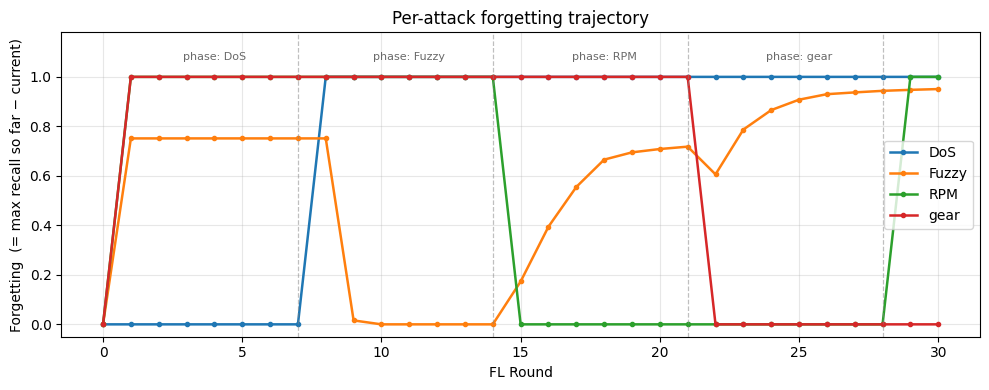

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_forgetting_metric.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for atk in ATTACK_TYPES:
    rec = slow[f'recall_{atk}'].values
    running_max = np.maximum.accumulate(rec)
    forgetting  = running_max - rec
    ax.plot(slow['round'], forgetting, marker='o', markersize=3, label=atk, linewidth=1.8)

for p in range(len(ATTACK_TYPES)):
    ax.axvline(x=(p+1)*ROUNDS_PER_PHASE, color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
    ax.text((p+0.5)*ROUNDS_PER_PHASE + 0.5, 1.07,
            f'phase: {ATTACK_TYPES[p]}', ha='center', fontsize=8, color='dimgray')

ax.set_xlabel('FL Round'); ax.set_ylabel('Forgetting  (= max recall so far − current)')
ax.set_title('Per-attack forgetting trajectory'); ax.legend(loc='center right')
ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.18)
plt.tight_layout()
out = FIG_DIR / 'fig_forgetting_metric.png'
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out}')

## 3. NL fast vs slow — per-attack trajectories with phase markers

Thick black line: slow (global). Blue band + dashed line: fast (per-client range and mean). Green shading: the rounds where that attack was the active task.

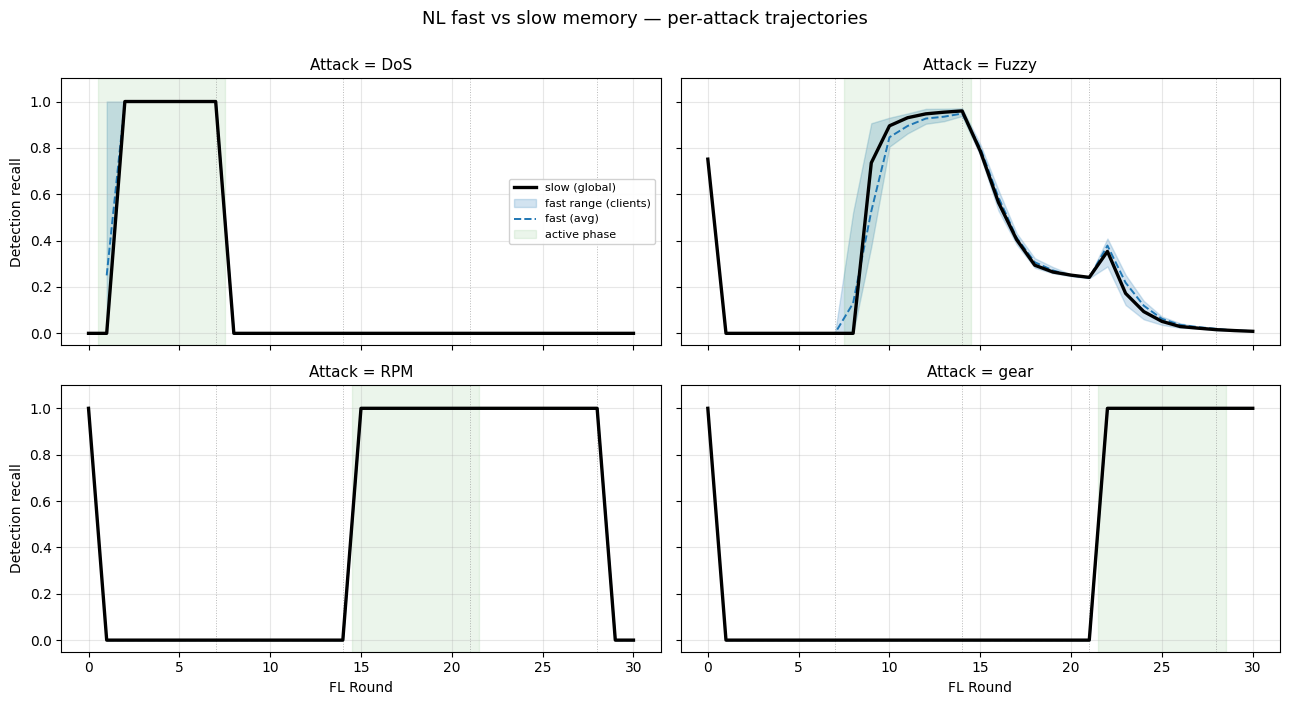

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_fast_vs_slow.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ai, atk in enumerate(ATTACK_TYPES):
    ax = axes[ai]
    # slow (global) — heavy black line
    ax.plot(slow['round'], slow[f'recall_{atk}'], color='black',
            linewidth=2.4, label='slow (global)', zorder=3)
    # fast (per-client): min-max band + dashed mean
    fa = fast[fast['attack']==atk]
    pv = fa.pivot(index='round', columns='client_id', values='fast_recall')
    ax.fill_between(pv.index, pv.min(axis=1), pv.max(axis=1),
                    alpha=0.20, color='C0', label='fast range (clients)')
    ax.plot(pv.index, pv.mean(axis=1), color='C0',
            linewidth=1.4, linestyle='--', label='fast (avg)')
    # phase grid
    for p in range(len(ATTACK_TYPES)):
        ax.axvline(x=(p+1)*ROUNDS_PER_PHASE, color='gray', linestyle=':', linewidth=0.7, alpha=0.55)
    # green shading where this attack was the active task
    apx = ATTACK_TYPES.index(atk)
    ax.axvspan(apx*ROUNDS_PER_PHASE + 0.5, (apx+1)*ROUNDS_PER_PHASE + 0.5,
               alpha=0.08, color='green',
               label='active phase' if ai==0 else None)
    ax.set_title(f'Attack = {atk}', fontsize=11)
    ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.1)
    if ai == 0: ax.legend(loc='center right', fontsize=8, framealpha=0.9)
    if ai >= 2: ax.set_xlabel('FL Round')
    if ai % 2 == 0: ax.set_ylabel('Detection recall')

fig.suptitle('NL fast vs slow memory — per-attack trajectories', fontsize=13, y=1.00)
plt.tight_layout()
out = FIG_DIR / 'fig_fast_vs_slow.png'
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out}')

## 4. Consolidation gap |fast − slow| over rounds

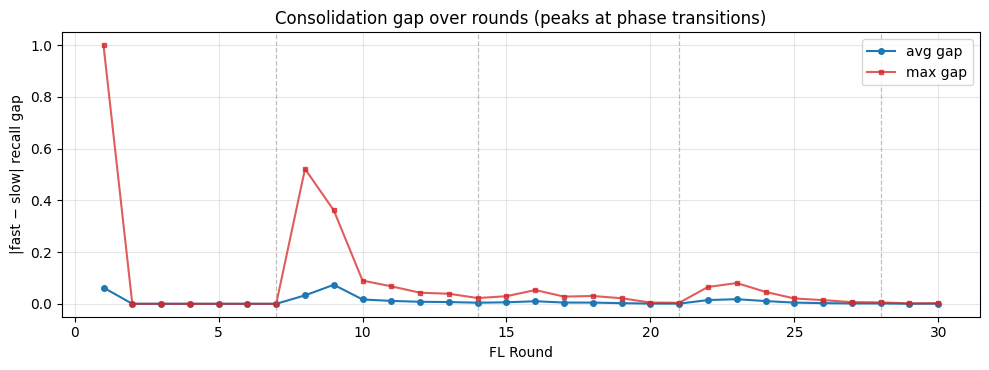

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_consolidation_gap.png

Phase-transition rounds [1, 8, 15, 22]: avg |fast−slow| = 0.0288
Steady-state rounds:                       avg |fast−slow| = 0.0070
→ Transition is 4.1× larger than steady state.


In [5]:
rows = []
for r in sorted(fast['round'].unique()):
    sf = fast[fast['round']==r]
    ss = slow[slow['round']==r].iloc[0]
    gaps = []
    for atk in ATTACK_TYPES:
        sv = ss[f'recall_{atk}']
        for fv in sf[sf['attack']==atk]['fast_recall'].values:
            gaps.append(abs(fv - sv))
    rows.append((r, float(np.mean(gaps)), float(np.max(gaps))))
gap_df = pd.DataFrame(rows, columns=['round','avg_gap','max_gap'])

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(gap_df['round'], gap_df['avg_gap'], marker='o', markersize=4, label='avg gap', color='C0')
ax.plot(gap_df['round'], gap_df['max_gap'], marker='s', markersize=3, label='max gap', color='C3', alpha=0.75)
for p in range(len(ATTACK_TYPES)):
    ax.axvline(x=(p+1)*ROUNDS_PER_PHASE, color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
ax.set_xlabel('FL Round'); ax.set_ylabel('|fast − slow| recall gap')
ax.set_title('Consolidation gap over rounds (peaks at phase transitions)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
out = FIG_DIR / 'fig_consolidation_gap.png'
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out}')

# Numbers
trans_rounds = [1, ROUNDS_PER_PHASE+1, 2*ROUNDS_PER_PHASE+1, 3*ROUNDS_PER_PHASE+1]
trans  = gap_df[gap_df['round'].isin(trans_rounds)]['avg_gap'].mean()
steady = gap_df[~gap_df['round'].isin(trans_rounds)]['avg_gap'].mean()
print(f'\nPhase-transition rounds {trans_rounds}: avg |fast−slow| = {trans:.4f}')
print(f'Steady-state rounds:                       avg |fast−slow| = {steady:.4f}')
print(f'→ Transition is {trans/max(steady,1e-9):.1f}× larger than steady state.')

## 5. Headline numbers (for the paper)

In [6]:
print('='*64); print('Numbers to cite in the paper (Results section)'); print('='*64)
print(f'Setup: {N_ROUNDS} FL rounds | 4 clients | sequential CFL ({ROUNDS_PER_PHASE} rounds/phase)')
print(f'Phase order: ' + ' -> '.join(ATTACK_TYPES))

print(f'\n{"Attack":<8} {"first":>8} {"best":>8} {"final":>8} {"forgetting":>12}')
print('-'*48)
for atk in ATTACK_TYPES:
    rec = slow[f'recall_{atk}'].values
    print(f'{atk:<8} {rec[1]:>8.3f} {rec.max():>8.3f} {rec[-1]:>8.3f} {rec.max()-rec[-1]:>+12.3f}')

print('\n' + '='*64); print('Consolidation gap (fast vs slow)'); print('='*64)
print(f'Phase-transition rounds: avg |fast−slow| = {trans:.4f}')
print(f'Steady-state rounds:     avg |fast−slow| = {steady:.4f}')
print(f'Ratio: {trans/max(steady,1e-9):.1f}x')

print('\n' + '='*64); print('Paper narrative (the four key sentences)'); print('='*64)
print('1. The global (slow) model retains only the most recently seen attack — standard CFL forgetting reproduced.')
print('2. The local (fast) models adapt within one round at a phase transition; slow lags behind.')
print('3. That lag = consolidation cost — a new signal made visible by the NL view.')
print('4. SHAP/Shapley (static feature- or client-attribution snapshots) cannot capture this temporal dynamic.')

print('\nFigures saved:')
for p in sorted(FIG_DIR.glob('fig_*.png')):
    print(f'  {p.name}  ({p.stat().st_size/1e3:.0f} KB)')

Numbers to cite in the paper (Results section)
Setup: 30 FL rounds | 4 clients | sequential CFL (7 rounds/phase)
Phase order: DoS -> Fuzzy -> RPM -> gear

Attack      first     best    final   forgetting
------------------------------------------------
DoS         0.000    1.000    0.000       +1.000
Fuzzy       0.000    0.959    0.009       +0.951
RPM         0.000    1.000    0.000       +1.000
gear        0.000    1.000    1.000       +0.000

Consolidation gap (fast vs slow)
Phase-transition rounds: avg |fast−slow| = 0.0288
Steady-state rounds:     avg |fast−slow| = 0.0070
Ratio: 4.1x

Paper narrative (the four key sentences)
1. The global (slow) model retains only the most recently seen attack — standard CFL forgetting reproduced.
2. The local (fast) models adapt within one round at a phase transition; slow lags behind.
3. That lag = consolidation cost — a new signal made visible by the NL view.
4. SHAP/Shapley (static feature- or client-attribution snapshots) cannot capture this t